## Visualize Encoding Patterns

In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
import os

from pathlib import Path
from itertools import islice
sys.path.append(os.path.abspath('..'))

In [3]:
from src.positional_encodings import SinusoidalPositionalEncoding

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
batch_size = 32
seq_len = 20
vocab_size = 1000
d_model = 128

In [6]:
#fake input sentences
X = torch.randn(batch_size, seq_len, d_model).to(device)

In [ ]:
encoding = SinusoidalPositionalEncoding(d_model,vocab_size)

pe = encoding.pe

print(pe.shape)


torch.Size([1000, 128])
torch.Size([32, 20, 128])
torch.Size([20, 128])


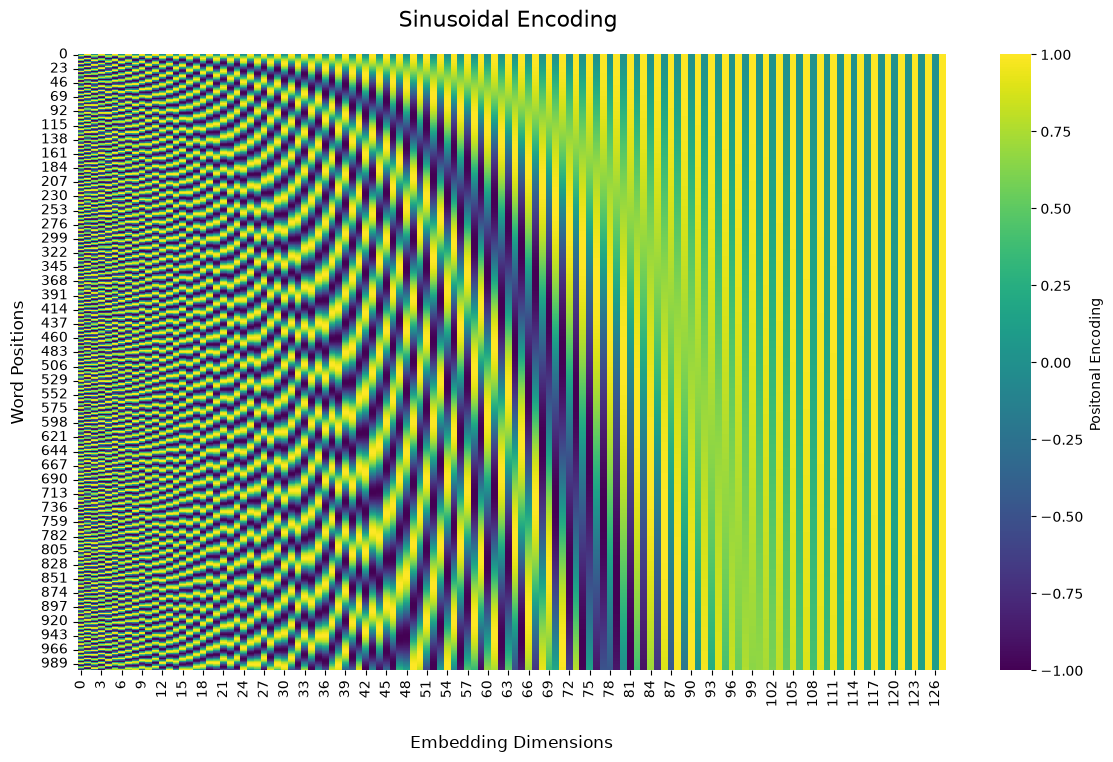

Heatmap successfully saved to: ../experiments/pe_heatmap.png


In [14]:

matrix_to_plot = pe.detach().cpu().numpy()

# Set up the plot size
plt.figure(figsize=(14, 8))

# 2. Configure the heatmap
sns.heatmap(matrix_to_plot, 
            cmap='viridis', 
            # 3. Use an accurate label for attention weights (0.0 to 1.0)
            cbar_kws={'label': 'Positonal Encoding '})

# 4. Apply RIGOROUS, accurate professional labels
plt.title("Sinusoidal Encoding ", fontsize=16, pad=20)

plt.ylabel("Word Positions", fontsize=12, labelpad=10) 
plt.xlabel("Embedding Dimensions", fontsize=12, labelpad=20)



# Save the final figure
filepath = Path('./../experiments/pe_heatmap.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()
print(f"Heatmap successfully saved to: {filepath}")